# Image Classification Pipeline
This notebook demonstrates an image classification workflow using cell-level features. Steps include data loading, preprocessing, feature extraction, model training, evaluation, and prediction visualization.

In [1]:
# Section 1: Import Required Libraries
import os
import numpy as np
import pandas as pd
from skimage.feature import hog
from skimage import io, color
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

## Section 2: Load and Preprocess Image Data
Load the annotation CSV and prepare the image dataset. Images are split into 8x8 cells, and features are extracted for each cell.

In [2]:
# Configuration
image_dir = r"C:\\Users\\pravi\\PG IITB\\cricket_object_detection\\data\\train_modified\\"
annotation_csv = r"C:\\Users\\pravi\\PG IITB\\cricket_object_detection\\outputs\\annotations_cells_modified.csv"
cell_height, cell_width = 75, 100  # For 800x600 images, 8x8 grid

# Load annotations
df = pd.read_csv(annotation_csv, encoding='latin1')

#group by image_name and get images having count > 64


In [3]:
# Feature extraction function
def extract_cell_features(cell_img):
    gray = color.rgb2gray(cell_img)
    hog_feat = hog(gray, pixels_per_cell=(8,8), cells_per_block=(1,1), feature_vector=True)
    mean = gray.mean()
    std = gray.std()
    return np.concatenate([hog_feat, [mean, std]])

# Prepare features and labels
feature_rows = []
img_files = df['image_name'].unique()
np.random.seed(42)
#img_files_sample = np.random.choice(img_files, size=min(150, len(img_files)), replace=False)

print("Total images to process:", len(img_files))

for img_name in img_files:
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        continue
    img = io.imread(img_path)
    if img.shape[0] != 600 or img.shape[1] != 800:
        continue
    cell_labels = df[df['image_name'] == img_name].sort_values(['cell_row', 'cell_column'])[['cell_row', 'cell_column', 'label']].values
    idx = 0
    for r in range(8):
        for c in range(8):
            y1, y2 = r*cell_height, (r+1)*cell_height
            x1, x2 = c*cell_width, (c+1)*cell_width
            cell_img = img[y1:y2, x1:x2]
            features = extract_cell_features(cell_img)
            cell_row, cell_col, label = cell_labels[idx]
            row = {
                'image_name': img_name,
                'cell_row': cell_row,
                'cell_column': cell_col,
                'label': label
            }
            for i, val in enumerate(features):
                row[f'feat_{i}'] = val
            feature_rows.append(row)
            idx += 1
features_df = pd.DataFrame(feature_rows)
print("Extracted features for", len(features_df), "cells")

Total images to process: 202
Extracted features for 12864 cells


## Section 3: Define Model Architecture
Train Random Forest and KNN classifiers using the extracted cell features.

In [16]:
# Prepare X, y for training
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
# Apply SelectKBest to select top features
X_raw = features_df[[col for col in features_df.columns if col.startswith('feat_')]].values
y = features_df['label'].values

# Choose number of top features (e.g., 100, can tune)
selector = SelectKBest(score_func=f_classif, k=100)
X_selected = selector.fit_transform(X_raw, y)
print(f'SelectKBest reduced feature shape: {X_selected.shape}')

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Random Forest (with class_weight)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# KNN (no class_weight, but can use SMOTE if needed)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

# For SVM and Logistic Regression, use a smaller sample for speed and scale features, with class_weight
svm_sample_size = min(3000, X_train.shape[0])
logreg_sample_size = min(3000, X_train.shape[0])
svm_idx = np.random.choice(X_train.shape[0], svm_sample_size, replace=False)
logreg_idx = np.random.choice(X_train.shape[0], logreg_sample_size, replace=False)

# Scale features for SVM and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Support Vector Machine (Linear kernel for speed, with class_weight)
from sklearn.svm import LinearSVC
svm_clf = LinearSVC(max_iter=1000, random_state=42, class_weight='balanced')
svm_clf.fit(X_train_scaled[svm_idx], y_train[svm_idx])

# Logistic Regression (saga solver for speed, with class_weight)
from sklearn.linear_model import LogisticRegression
logreg_clf = LogisticRegression(max_iter=500, solver='saga', random_state=42, class_weight='balanced')
logreg_clf.fit(X_train_scaled[logreg_idx], y_train[logreg_idx])

SelectKBest reduced feature shape: (12864, 100)


LogisticRegression(class_weight='balanced', max_iter=500, random_state=42,
                   solver='saga')

In [17]:
# --- Apply SMOTE to balance classes for KNN (and optionally others) ---
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print('After SMOTE:', np.bincount(y_train_smote))

# Re-train KNN on SMOTE-balanced data
knn_clf_smote = KNeighborsClassifier(n_neighbors=5)
knn_clf_smote.fit(X_train_smote, y_train_smote)

After SMOTE: [6643 6643 6643 6643]


KNeighborsClassifier()

## Section 4: Train the Model
Training was performed above. Now, evaluate the trained models.

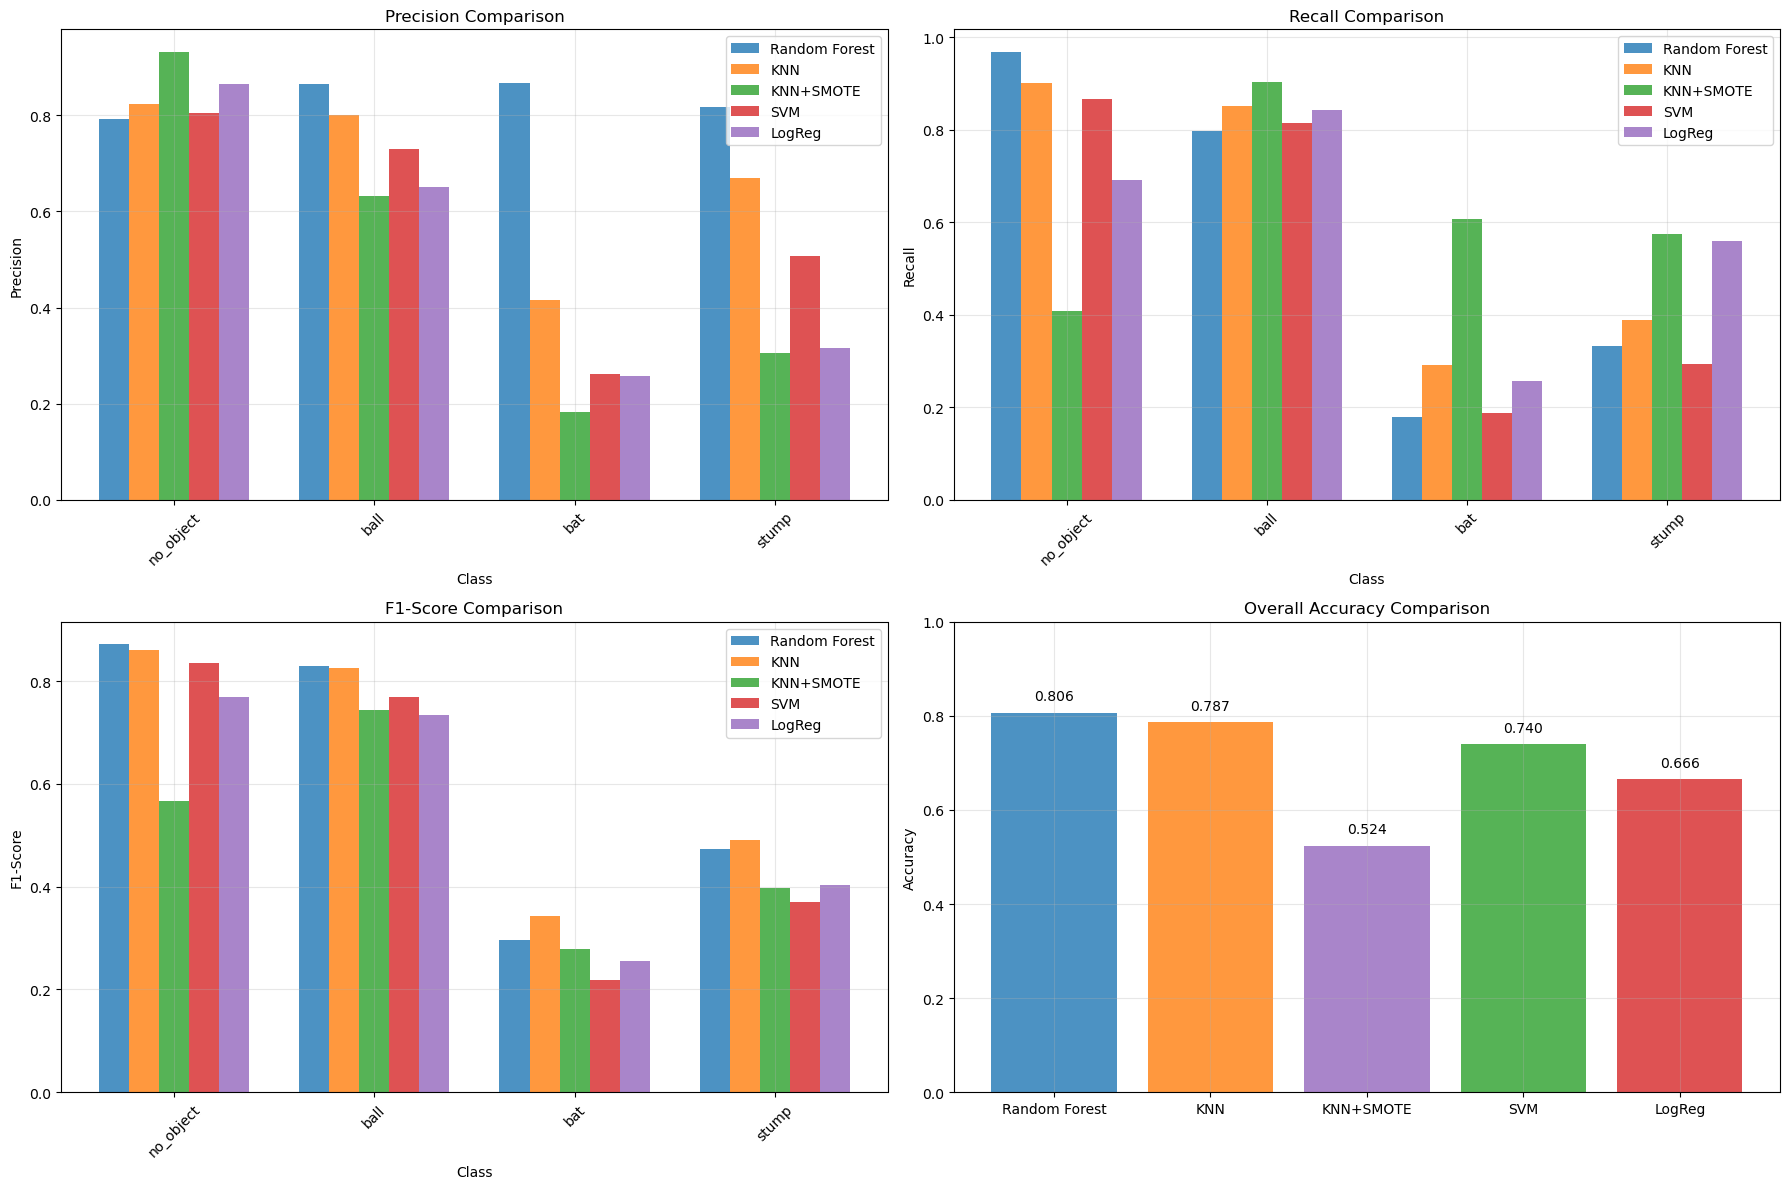


=== Model Comparison Summary ===

    Class  RF Precision  KNN Precision  KNN+SMOTE Precision  SVM Precision  LogReg Precision  RF Recall  KNN Recall  KNN+SMOTE Recall  SVM Recall  LogReg Recall  RF F1-Score  KNN F1-Score  KNN+SMOTE F1-Score  SVM F1-Score  LogReg F1-Score
no_object      0.793001       0.824600             0.932600       0.805820          0.864662   0.968694    0.900060          0.408188    0.866948       0.692354     0.872087      0.860679            0.567839      0.835267         0.768974
     ball      0.866324       0.801782             0.631405       0.729387          0.650823   0.796690    0.851064          0.903073    0.815603       0.841608     0.830049      0.825688            0.743191      0.770089         0.734021
      bat      0.866667       0.415584             0.181694       0.261146          0.256881   0.178082    0.292237          0.607306    0.187215       0.255708     0.295455      0.343164            0.279706      0.218085         0.256293
    stump

In [18]:
# Evaluate Model Performance (with SMOTE KNN included)
labels = [0, 1, 2, 3]
class_names = ['no_object', 'ball', 'bat', 'stump']
rf_pred = rf_clf.predict(X_test)
knn_pred = knn_clf.predict(X_test)
svm_pred = svm_clf.predict(X_test)
logreg_pred = logreg_clf.predict(X_test)
knn_smote_pred = knn_clf_smote.predict(X_test)  # KNN trained on SMOTE data

# Compute metrics for all models
rf_metrics = precision_recall_fscore_support(y_test, rf_pred, labels=labels, average=None)
knn_metrics = precision_recall_fscore_support(y_test, knn_pred, labels=labels, average=None)
svm_metrics = precision_recall_fscore_support(y_test, svm_pred, labels=labels, average=None)
logreg_metrics = precision_recall_fscore_support(y_test, logreg_pred, labels=labels, average=None)
knn_smote_metrics = precision_recall_fscore_support(y_test, knn_smote_pred, labels=labels, average=None)

rf_accuracy = accuracy_score(y_test, rf_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)
logreg_accuracy = accuracy_score(y_test, logreg_pred)
knn_smote_accuracy = accuracy_score(y_test, knn_smote_pred)

# Create comparison dataframe
comparison_data = {
    'Class': class_names,
    'RF Precision': rf_metrics[0],
    'KNN Precision': knn_metrics[0],
    'KNN+SMOTE Precision': knn_smote_metrics[0],
    'SVM Precision': svm_metrics[0],
    'LogReg Precision': logreg_metrics[0],
    'RF Recall': rf_metrics[1],
    'KNN Recall': knn_metrics[1],
    'KNN+SMOTE Recall': knn_smote_metrics[1],
    'SVM Recall': svm_metrics[1],
    'LogReg Recall': logreg_metrics[1],
    'RF F1-Score': rf_metrics[2],
    'KNN F1-Score': knn_metrics[2],
    'KNN+SMOTE F1-Score': knn_smote_metrics[2],
    'SVM F1-Score': svm_metrics[2],
    'LogReg F1-Score': logreg_metrics[2]
}
comparison_df = pd.DataFrame(comparison_data)

# Plot comparison (add KNN+SMOTE)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

bar_width = 0.15
x = np.arange(len(class_names))

# Precision comparison
axes[0, 0].bar(x - 2*bar_width, rf_metrics[0], bar_width, label='Random Forest', alpha=0.8)
axes[0, 0].bar(x - bar_width, knn_metrics[0], bar_width, label='KNN', alpha=0.8)
axes[0, 0].bar(x, knn_smote_metrics[0], bar_width, label='KNN+SMOTE', alpha=0.8)
axes[0, 0].bar(x + bar_width, svm_metrics[0], bar_width, label='SVM', alpha=0.8)
axes[0, 0].bar(x + 2*bar_width, logreg_metrics[0], bar_width, label='LogReg', alpha=0.8)
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Precision Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(class_names, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Recall comparison
axes[0, 1].bar(x - 2*bar_width, rf_metrics[1], bar_width, label='Random Forest', alpha=0.8)
axes[0, 1].bar(x - bar_width, knn_metrics[1], bar_width, label='KNN', alpha=0.8)
axes[0, 1].bar(x, knn_smote_metrics[1], bar_width, label='KNN+SMOTE', alpha=0.8)
axes[0, 1].bar(x + bar_width, svm_metrics[1], bar_width, label='SVM', alpha=0.8)
axes[0, 1].bar(x + 2*bar_width, logreg_metrics[1], bar_width, label='LogReg', alpha=0.8)
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Recall Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(class_names, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1-Score comparison
axes[1, 0].bar(x - 2*bar_width, rf_metrics[2], bar_width, label='Random Forest', alpha=0.8)
axes[1, 0].bar(x - bar_width, knn_metrics[2], bar_width, label='KNN', alpha=0.8)
axes[1, 0].bar(x, knn_smote_metrics[2], bar_width, label='KNN+SMOTE', alpha=0.8)
axes[1, 0].bar(x + bar_width, svm_metrics[2], bar_width, label='SVM', alpha=0.8)
axes[1, 0].bar(x + 2*bar_width, logreg_metrics[2], bar_width, label='LogReg', alpha=0.8)
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(class_names, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Overall Accuracy comparison
model_names = ['Random Forest', 'KNN', 'KNN+SMOTE', 'SVM', 'LogReg']
accuracies = [rf_accuracy, knn_accuracy, knn_smote_accuracy, svm_accuracy, logreg_accuracy]
axes[1, 1].bar(model_names, accuracies, color=['#1f77b4', '#ff7f0e', '#9467bd', '#2ca02c', '#d62728'], alpha=0.8)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Overall Accuracy Comparison')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3)
for i, (model, acc) in enumerate(zip(model_names, accuracies)):
    axes[1, 1].text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\n=== Model Comparison Summary ===\n")
print(comparison_df.to_string(index=False))
print(f"\n{'='*60}")
for model, acc in zip(model_names, accuracies):
    print(f"{model} Accuracy: {acc:.4f}")
print(f"{'='*60}")

## Section 5: Make Predictions on New Images
Use the trained Random Forest model to predict cell labels for new images and save results to CSV.

In [13]:
# Save Model Predictions to CSV
from sklearn.model_selection import train_test_split

def save_final_predictions(features_df, rf_clf, image_dir, cell_height, cell_width):
    import csv
    # Get unique image names
    unique_images = features_df['image_name'].unique()
    # Split images into train and test sets (80/20)
    train_imgs, test_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)
    print(f"Number of train images: {len(train_imgs)}")
    print(f"Number of test images: {len(test_imgs)}")
    print(f"Overlap: {len(set(train_imgs).intersection(set(test_imgs)))}")
    def predict_and_save(img_list, dataset_type, model, out_writer):
        for img_name in img_list:
            img_path = os.path.join(image_dir, img_name)
            if not os.path.exists(img_path):
                continue
            img = io.imread(img_path)
            if img.shape[0] != 600 or img.shape[1] != 800:
                continue
            preds = []
            for r in range(8):
                for c in range(8):
                    y1, y2 = r*cell_height, (r+1)*cell_height
                    x1, x2 = c*cell_width, (c+1)*cell_width
                    cell_img = img[y1:y2, x1:x2]
                    features = extract_cell_features(cell_img)
                    pred = model.predict([features])[0]
                    preds.append(pred)
            row = [img_name, dataset_type] + preds
            out_writer.writerow(row)
    output_csv_path = r"C:\Users\pravi\PG IITB\cricket_object_detection\outputs\final_predictions_test.csv"
    with open(output_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        header = ['ImageFileName', 'TrainOrTest'] + [f'c{str(i+1).zfill(2)}' for i in range(64)]
        writer.writerow(header)
        predict_and_save(train_imgs, 'Train', rf_clf, writer)
        predict_and_save(test_imgs, 'Test', rf_clf, writer)
    print(f"Final predictions saved to {output_csv_path}")

save_final_predictions(features_df, rf_clf, image_dir, cell_height, cell_width)


Number of train images: 160
Number of test images: 41
Overlap: 0
Final predictions saved to C:\Users\pravi\PG IITB\cricket_object_detection\outputs\final_predictions_test.csv
Final predictions saved to C:\Users\pravi\PG IITB\cricket_object_detection\outputs\final_predictions_test.csv
